2. Category-Price Correlation

Question: Which book categories command premium prices, and how stable are these price hierarchies across decades?

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Connect to your database
conn = duckdb.connect('amazon_books.ddb')

In [3]:
# ======================
# 1. DATA PREPARATION
# ======================

# Get books with sufficient data (1900s onward for better coverage)
book_prices_query = """
    WITH price_mode AS (
        SELECT 
            Title,
            Price as book_price,
            COUNT(*) as frequency
        FROM reviews
        WHERE Price IS NOT NULL 
          AND Price > 0 
          AND Price < 200  -- Reasonable book price range
        GROUP BY Title, Price
    ),
    ranked_prices AS (
        SELECT 
            Title,
            book_price,
            frequency,
            ROW_NUMBER() OVER (PARTITION BY Title ORDER BY frequency DESC) as rank
        FROM price_mode
    )
    SELECT 
        b.Title,
        b.primary_category,
        b.Decade,
        rp.book_price
    FROM books b
    INNER JOIN ranked_prices rp ON b.Title = rp.Title
    WHERE rp.rank = 1
      AND b.Decade >= 1900
      AND b.primary_category IS NOT NULL
      AND b.primary_category != ''
"""

data = conn.execute(book_prices_query).fetchdf()
print(f"{len(data):,} books with price data")


39,175 books with price data


In [4]:
# ======================
# 2. CATEGORY RANKINGS
# ======================
print("CATEGORY PRICE RANKINGS...")

category_stats = data.groupby('primary_category').agg({
    'book_price': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'Title': 'nunique'
}).round(2)

# Flatten column names
category_stats.columns = ['book_count', 'mean_price', 'median_price', 
                         'price_std', 'min_price', 'max_price', 'unique_titles']
category_stats = category_stats[category_stats['book_count'] >= 20]  # Minimum 20 books
category_stats = category_stats.sort_values('mean_price', ascending=False)

print(f"ANALYZED {len(category_stats)} CATEGORIES:")
print("-" * 60)

# Display top and bottom categories
print("TOP 10 MOST EXPENSIVE CATEGORIES:")
top_categories = category_stats.head(10).reset_index()
for i, row in top_categories.iterrows():
    print(f"{i+1:2d}. {row['primary_category'][:30]:30} ${row['mean_price']:6.2f} (n={row['book_count']:4d})")

print("TOP 10 LEAST EXPENSIVE CATEGORIES:")
bottom_categories = category_stats.tail(10).reset_index()
for i, row in bottom_categories.iterrows():
    print(f"{i+1:2d}. {row['primary_category'][:30]:30} ${row['mean_price']:6.2f} (n={row['book_count']:4d})")

CATEGORY PRICE RANKINGS...
ANALYZED 59 CATEGORIES:
------------------------------------------------------------
TOP 10 MOST EXPENSIVE CATEGORIES:
 1. Technology & Engineering       $ 52.54 (n= 520)
 2. Mathematics                    $ 50.70 (n= 405)
 3. Medical                        $ 47.07 (n= 515)
 4. Science                        $ 46.46 (n= 799)
 5. Language Arts & Disciplines    $ 45.10 (n= 670)
 6. Law                            $ 44.67 (n= 247)
 7. Literary Criticism             $ 43.44 (n= 784)
 8. Social Science                 $ 41.06 (n=1238)
 9. Psychology                     $ 38.47 (n= 644)
10. Computers                      $ 38.45 (n=1495)
TOP 10 LEAST EXPENSIVE CATEGORIES:
 1. Crafts & Hobbies               $ 16.72 (n= 259)
 2. Body, Mind & Spirit            $ 15.77 (n= 689)
 3. Travel                         $ 15.58 (n= 338)
 4. Juvenile Nonfiction            $ 14.92 (n= 877)
 5. Young Adult Fiction            $ 14.84 (n= 102)
 6. Self-Help                      $ 14

In [5]:
# ======================
# 3. PRICE RANGES HIGHLIGHT
# ======================
print("PRICE RANGES & VARIABILITY...")

overall_stats = {
    'Overall Mean': data['book_price'].mean(),
    'Overall Median': data['book_price'].median(),
    'Price Range': f"${data['book_price'].min():.2f} - ${data['book_price'].max():.2f}",
    'Standard Deviation': data['book_price'].std(),
    '75th Percentile': data['book_price'].quantile(0.75),
    '25th Percentile': data['book_price'].quantile(0.25),
    'IQR': data['book_price'].quantile(0.75) - data['book_price'].quantile(0.25)
}

print("OVERALL PRICE STATISTICS:")
print("-" * 40)
for key, value in overall_stats.items():
    print(f"{key:25}: {value}")

PRICE RANGES & VARIABILITY...
OVERALL PRICE STATISTICS:
----------------------------------------
Overall Mean             : 27.32274511805998
Overall Median           : 17.95
Price Range              : $1.00 - $199.95
Standard Deviation       : 28.017257889166174
75th Percentile          : 29.95
25th Percentile          : 11.99
IQR                      : 17.96


In [6]:
# ======================
# 4. VISUALIZATIONS
# ======================
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

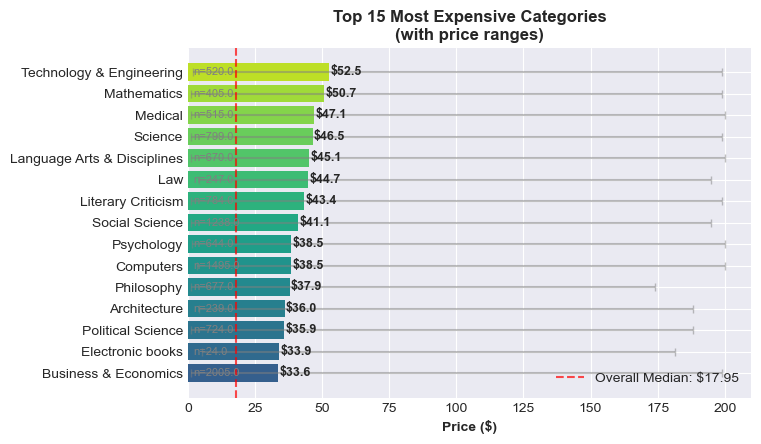

In [7]:
fig = plt.figure(figsize=(16, 10))


# Plot 1: Top Categories Bar Chart
ax1 = plt.subplot(2, 2, 1)
top_n = min(15, len(category_stats))
plot_data = category_stats.head(top_n).copy()
plot_data = plot_data.sort_values('mean_price', ascending=True)

bars = ax1.barh(plot_data.index, plot_data['mean_price'], 
                color=plt.cm.viridis(np.linspace(0.3, 0.9, top_n)))

# Add error bars for price ranges
ax1.errorbar(plot_data['mean_price'], plot_data.index,
             xerr=[plot_data['mean_price'] - plot_data['min_price'], 
                   plot_data['max_price'] - plot_data['mean_price']],
             fmt='none', ecolor='gray', alpha=0.5, capsize=3)

ax1.set_xlabel('Price ($)', fontweight='bold')
ax1.set_title(f'Top {top_n} Most Expensive Categories\n(with price ranges)', fontweight='bold')
ax1.axvline(x=data['book_price'].median(), color='red', linestyle='--', 
            alpha=0.7, label=f'Overall Median: ${data["book_price"].median():.2f}')

# Add price labels
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax1.text(row['mean_price'] + 0.5, i, f'${row["mean_price"]:.1f}', 
             va='center', ha='left', fontsize=9, fontweight='bold')
    ax1.text(2, i, f'n={row["book_count"]}', 
             va='center', ha='left', fontsize=8, color='gray')

ax1.legend(loc='lower right')


In [8]:
# Calculate price statistics by category and decade
price_stability = data.groupby(['primary_category', 'Decade']).agg({
    'book_price': ['count', 'mean', 'std', 'min', 'max', 'median']
}).round(2)

# Flatten the multi-index columns
price_stability.columns = ['_'.join(col).strip() for col in price_stability.columns]
price_stability = price_stability.reset_index()

# Remove categories with insufficient data (at least 3 decades of data)
category_decade_counts = price_stability.groupby('primary_category')['Decade'].nunique()
categories_with_enough_data = category_decade_counts[category_decade_counts >= 3].index.tolist()
price_stability = price_stability[price_stability['primary_category'].isin(categories_with_enough_data)]

print(f"Analyzing {len(categories_with_enough_data)} categories with sufficient data")

Analyzing 149 categories with sufficient data


In [9]:
# Use weighted statistics where larger samples have more influence
def calculate_weighted_stability(group):
    """Calculate stability metrics with weights based on sample size"""
    # Weight each decade by number of books (sqrt of count for moderate weighting)
    weights = np.sqrt(group['book_price_count'])
    
    # Weighted mean price
    weighted_mean = np.average(group['book_price_mean'], weights=weights)
    
    # Weighted standard deviation
    weighted_var = np.average((group['book_price_mean'] - weighted_mean)**2, weights=weights)
    weighted_std = np.sqrt(weighted_var)
    
    # Weighted coefficient of variation
    weighted_cv = weighted_std / weighted_mean if weighted_mean > 0 else np.nan
    
    # Overall sample size
    total_books = group['book_price_count'].sum()
    
    # Confidence in stability estimate (higher with more data)
    confidence = min(1.0, total_books / 100)  # 100 books = full confidence
    
    return pd.Series({
        'weighted_mean_price': weighted_mean,
        'weighted_cv': weighted_cv,
        'total_books': total_books,
        'confidence': confidence,
        'num_decades': len(group),
        'avg_books_per_decade': group['book_price_count'].mean()
    })

# First filter by minimum data requirements
min_books_per_decade = 3
min_decades = 3

# Filter out decade entries with too few books
filtered_data = price_stability[price_stability['book_price_count'] >= min_books_per_decade]

# Filter categories with enough decades
decade_counts = filtered_data.groupby('primary_category')['Decade'].nunique()
valid_categories = decade_counts[decade_counts >= min_decades].index.tolist()
filtered_data = filtered_data[filtered_data['primary_category'].isin(valid_categories)]

# Calculate weighted stability metrics
weighted_stability = filtered_data.groupby('primary_category').apply(calculate_weighted_stability)

# Sort by weighted CV (most stable first)
weighted_stability = weighted_stability.sort_values('weighted_cv')

# Filter by confidence (only include reliable estimates)
reliable_categories = weighted_stability[weighted_stability['confidence'] >= 0.7]

print(f"🔍 WEIGHTED STABILITY ANALYSIS:")
print(f"Categories with reliable data: {len(reliable_categories):,}")
print(f"Average confidence score: {reliable_categories['confidence'].mean():.2f}")
print(f"Average books per category: {reliable_categories['total_books'].mean():.0f}")

# Show top/bottom by weighted CV
print("\n🏆 TOP 5 MOST STABLE (Weighted CV):")
print(reliable_categories.nsmallest(5, 'weighted_cv')[['weighted_mean_price', 'weighted_cv', 'total_books', 'confidence']])

print("\n📉 TOP 5 LEAST STABLE (Weighted CV):")
print(reliable_categories.nlargest(5, 'weighted_cv')[['weighted_mean_price', 'weighted_cv', 'total_books', 'confidence']])

🔍 WEIGHTED STABILITY ANALYSIS:
Categories with reliable data: 50
Average confidence score: 0.99
Average books per category: 716

🏆 TOP 5 MOST STABLE (Weighted CV):
                     weighted_mean_price  weighted_cv  total_books  confidence
primary_category                                                              
Poetry                         17.456094     0.043055        600.0         1.0
Sports & Recreation            19.980555     0.056162        581.0         1.0
Body, Mind & Spirit            15.571775     0.060859        687.0         1.0
Self-Help                      14.309055     0.062196        493.0         1.0
Young Adult Fiction            14.734429     0.070290        101.0         1.0

📉 TOP 5 LEAST STABLE (Weighted CV):
                          weighted_mean_price  weighted_cv  total_books  \
primary_category                                                          
Design                              17.629077     0.342269         78.0   
Study Aids           

/var/folders/3t/dg_64gps7270wgpfzs5m83bw0000gp/T/ipykernel_1116/2087434515.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_stability = filtered_data.groupby('primary_category').apply(calculate_weighted_stability)


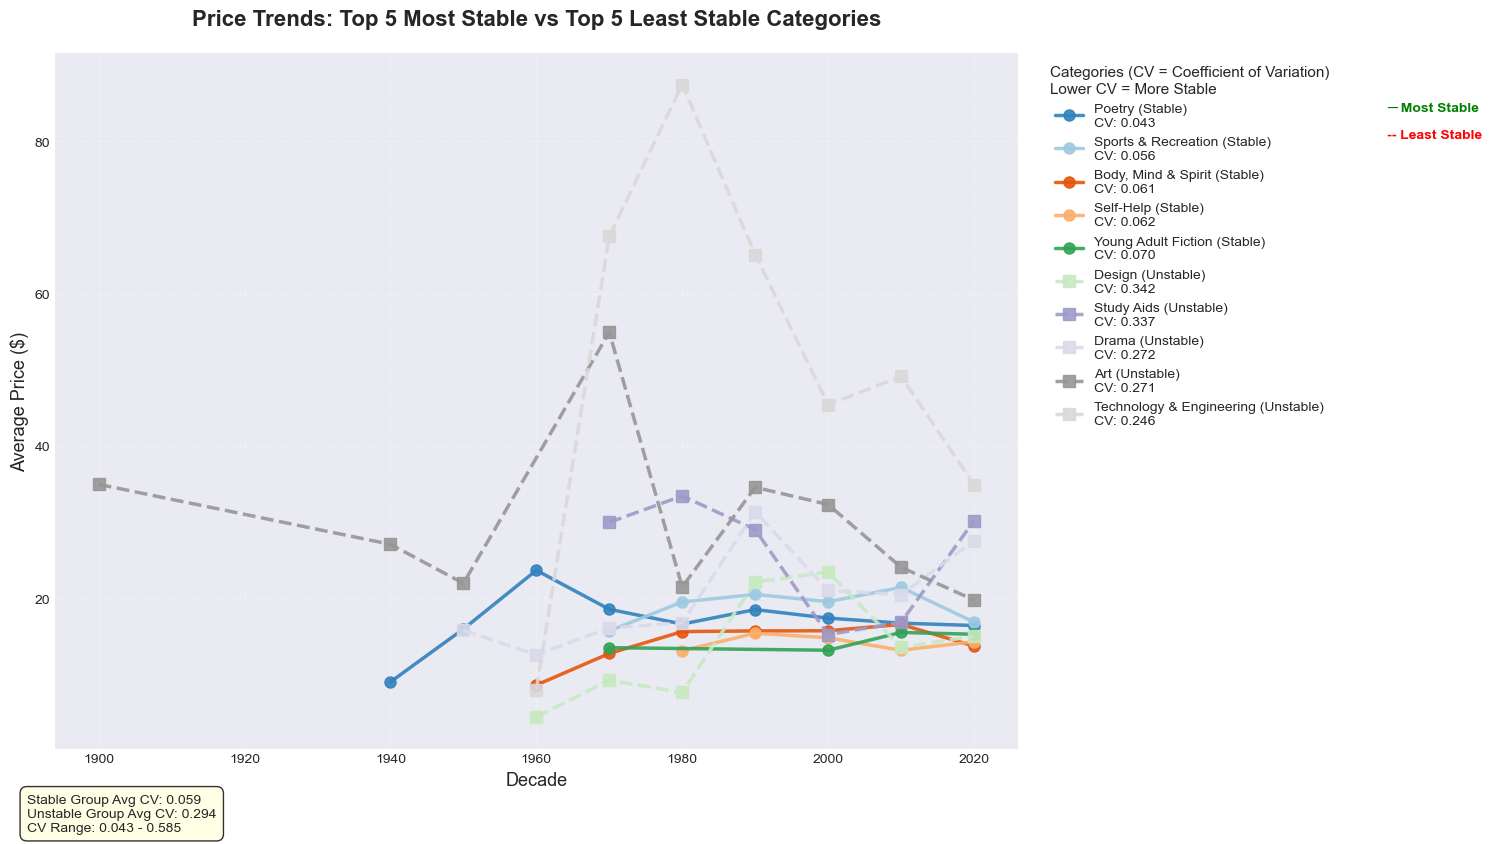

In [10]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Get top 5 most stable and top 5 least stable categories using your variables
top_stable = reliable_categories.nsmallest(5, 'weighted_cv').index.tolist()
top_unstable = reliable_categories.nlargest(5, 'weighted_cv').index.tolist()

# Filter price_stability data for these categories
stable_data = price_stability[price_stability['primary_category'].isin(top_stable)]
unstable_data = price_stability[price_stability['primary_category'].isin(top_unstable)]

# All categories in one chart
plt.figure(figsize=(16, 9))

# Create a color palette with distinct colors
colors = plt.cm.tab20c(np.linspace(0, 1, 10))

# Plot all categories
all_categories_to_plot = top_stable + top_unstable
line_styles = ['-'] * 5 + ['--'] * 5  # Solid for stable, dashed for unstable
markers = ['o'] * 5 + ['s'] * 5  # Circles for stable, squares for unstable

for idx, category in enumerate(all_categories_to_plot):
    if category in top_stable:
        cat_data = stable_data[stable_data['primary_category'] == category].sort_values('Decade')
        label_type = "(Stable)"
    else:
        cat_data = unstable_data[unstable_data['primary_category'] == category].sort_values('Decade')
        label_type = "(Unstable)"
    
    cv_value = reliable_categories.loc[category, 'weighted_cv']
    
    plt.plot(cat_data['Decade'], cat_data['book_price_mean'],
             color=colors[idx],
             marker=markers[idx],
             linewidth=2.5,
             linestyle=line_styles[idx],
             markersize=8,
             label=f"{category} {label_type}\nCV: {cv_value:.3f}",
             alpha=0.9)
    
    

# Customize the plot
plt.title('Price Trends: Top 5 Most Stable vs Top 5 Least Stable Categories', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Decade', fontsize=13)
plt.ylabel('Average Price ($)', fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')

# Create a custom legend with better formatting
legend = plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), 
                    fontsize=10, title="Categories (CV = Coefficient of Variation)\nLower CV = More Stable",
                    title_fontsize=11)

# Add a vertical line to separate stable and unstable in legend
plt.figtext(0.87, 0.82, "─ Most Stable", fontsize=10, fontweight='bold', color='green')
plt.figtext(0.87, 0.79, "-- Least Stable", fontsize=10, fontweight='bold', color='red')

# Add summary statistics using your variables
stable_cv_mean = weighted_stability.loc[top_stable, 'weighted_cv'].mean()
unstable_cv_mean = weighted_stability.loc[top_unstable, 'weighted_cv'].mean()

plt.figtext(0.02, 0.02, 
            f"Stable Group Avg CV: {stable_cv_mean:.3f}\nUnstable Group Avg CV: {unstable_cv_mean:.3f}\nCV Range: {weighted_stability['weighted_cv'].min():.3f} - {weighted_stability['weighted_cv'].max():.3f}",
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.05, 0.85, 0.95])  # Adjust for legend
plt.show()

In [11]:
conn.close()